# CICIoT2023 - Exploratory Data Analysis
**Project:** AI Based Alert Prioritization for Network Intrusion Detection

## 1. Imports and Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

## 2. Load Data & Basic Structure

In [6]:
data_dir = Path("data\MERGED_CSV")
dfs = []
for file in data_dir.iterdir():
    if file.is_file():
        df = pd.read_csv(data_dir / file.name)
        dfs.append(df)

df_complete = pd.concat(dfs)
df_complete

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,19.92,6,63.36,25893.962218,0.0,0.00,0.0,0.99,0.99,0.0,...,6421.0,60.0,481.0,64.21,42.100000,64.21,0.000039,100.0,1772.410000,DDOS-PSHACK_FLOOD
1,0.00,47,64.00,3703.841331,0.0,0.00,0.0,0.00,0.00,0.0,...,57320.0,98.0,578.0,573.20,48.000000,573.20,0.000271,100.0,2304.000000,MIRAI-GREIP_FLOOD
2,7.92,17,65.91,19673.095685,0.0,0.00,0.0,0.00,0.00,0.0,...,6010.0,60.0,70.0,60.10,1.000000,60.10,0.000057,100.0,1.000000,DOS-UDP_FLOOD
3,20.40,6,110.50,261.664826,0.1,0.00,0.3,0.20,0.40,0.0,...,2223.0,54.0,1500.0,222.30,451.596686,222.30,0.004766,10.0,203939.566667,DNS_SPOOFING
4,0.32,1,63.96,28944.199848,0.0,0.00,0.0,0.00,0.01,0.0,...,6006.0,60.0,66.0,60.06,0.600000,60.06,0.000035,100.0,0.360000,DDOS-ICMP_FLOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428156,20.00,6,64.00,33267.005076,0.0,1.00,0.0,0.00,0.00,0.0,...,6000.0,60.0,60.0,60.00,0.000000,60.00,0.000030,100.0,0.000000,DDOS-SYN_FLOOD
428157,20.00,6,64.00,8280.792087,0.0,1.00,0.0,0.00,0.00,0.0,...,6000.0,60.0,60.0,60.00,0.000000,60.00,0.000121,100.0,0.000000,DDOS-SYN_FLOOD
428158,20.00,6,64.00,31939.567469,0.0,0.00,0.0,0.00,0.00,0.0,...,6000.0,60.0,60.0,60.00,0.000000,60.00,0.000033,100.0,0.000000,DDOS-TCP_FLOOD
428159,8.24,17,65.55,3334.661589,0.0,0.01,0.0,0.00,0.00,0.0,...,6075.0,60.0,90.0,60.75,3.934758,60.75,0.000300,100.0,15.482323,DDOS-UDP_FLOOD


In [7]:
print(df_complete.shape)
print(df_complete.columns)

(45019243, 40)
Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label'],
      dtype='str')


## 3. Label Distribution

In [8]:
total = df_complete.shape[0]
# for x in df_complete["Label"].value_counts():
#     print(x)
print("Class Counts")
for index, value in df_complete["Label"].value_counts().items():
    print(f"{index}: {round((value/total)*100, 4)}%")

Class Counts
DDOS-ICMP_FLOOD: 15.3118%
DDOS-UDP_FLOOD: 11.5085%
DDOS-TCP_FLOOD: 9.565%
DDOS-PSHACK_FLOOD: 8.7082%
DDOS-SYN_FLOOD: 8.6322%
DDOS-RSTFINFLOOD: 8.6026%
DDOS-SYNONYMOUSIP_FLOOD: 7.6537%
DOS-UDP_FLOOD: 7.0577%
DOS-TCP_FLOOD: 5.6826%
DOS-SYN_FLOOD: 4.3141%
BENIGN: 2.3354%
MIRAI-GREETH_FLOOD: 2.1088%
MIRAI-UDPPLAIN: 1.8941%
MIRAI-GREIP_FLOOD: 1.5985%
DDOS-ICMP_FRAGMENTATION: 0.9622%
VULNERABILITYSCAN: 0.7943%
MITM-ARPSPOOFING: 0.6541%
DDOS-UDP_FRAGMENTATION: 0.6106%
DDOS-ACK_FRAGMENTATION: 0.6059%
DNS_SPOOFING: 0.3809%
RECON-HOSTDISCOVERY: 0.2858%
RECON-OSSCAN: 0.2087%
RECON-PORTSCAN: 0.1749%
DOS-HTTP_FLOOD: 0.1528%
DDOS-HTTP_FLOOD: 0.0613%
DDOS-SLOWLORIS: 0.0498%
DICTIONARYBRUTEFORCE: 0.0278%
BROWSERHIJACKING: 0.0125%
COMMANDINJECTION: 0.0115%
SQLINJECTION: 0.0112%
XSS: 0.0082%
BACKDOOR_MALWARE: 0.0068%
RECON-PINGSWEEP: 0.0048%
UPLOADING_ATTACK: 0.0027%


## 4. Data Quality

In [9]:
# NaNs
df_complete = df_complete.replace([np.inf, -np.inf], np.nan)
null_counts = df_complete.isnull().sum()
print("Null Counts: ")
print(null_counts[null_counts > 0])

# Drop NaNs
df_complete = df_complete.dropna()

# Duplicate rows
print("\nDuplicate Rows")
print(df_complete.duplicated().sum())

# Drop Duplicates
df_complete = df_complete.drop_duplicates()

df_complete.shape

Null Counts: 
Rate               991
fin_flag_number      1
syn_flag_number      1
rst_flag_number      2
psh_flag_number      2
ack_flag_number      2
ece_flag_number      2
cwr_flag_number      2
ack_count            2
syn_count            2
fin_count            2
rst_count            2
HTTP                 2
HTTPS                2
DNS                  3
Telnet               3
SMTP                 3
SSH                  3
IRC                  3
TCP                  4
UDP                  4
DHCP                 4
ARP                  6
ICMP                 6
IGMP                 6
IPv                  7
LLC                  7
Tot sum              7
Min                  7
Max                  7
AVG                  7
Std                677
Tot size             7
IAT                  7
Number               8
Variance           679
Label                9
dtype: int64

Duplicate Rows
24013569


(21004674, 40)

In [10]:
# Zero Variance Columns
print("Zero variance columns")
zero_var = df_complete.columns[df_complete.nunique() == 1]
print(zero_var)

# Drop zero variance columns
df_complete = df_complete.drop(columns=zero_var)
df_complete.shape

Zero variance columns
Index([], dtype='str')


(21004674, 40)

## 5. Feature Correlations

In [11]:
# Pearson correlation coefficient
corr_matrix = df_complete.iloc[:, :-1].corr()

In [13]:
# Identify highly correlated features
corr_matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.85 # Can fine tune threshold if needed
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .query('abs(correlation) >= @threshold')
    .sort_values('correlation', ascending=False)
    )
print(high_corr)

explicit_drop = {'fin_count', 'syn_count', 'rst_count', 'Tot size', 'LLC', 'ARP'}

to_drop = set(explicit_drop)
for _, row in high_corr.iterrows():
    if row['feature_1'] not in to_drop:
        to_drop.add(row['feature_2'])

print(f"\nFeatures to drop: {len(to_drop)}")
print(to_drop)

df_reduced = df_complete.drop(columns=to_drop)
print(f"\nRemaining features: {df_reduced.shape[1]}")

            feature_1        feature_2  correlation
1121              IPv              LLC     1.000000
1322              AVG         Tot size     1.000000
169   fin_flag_number        fin_count     0.997395
207   syn_flag_number        syn_count     0.992715
248   rst_flag_number        rst_count     0.989238
521         fin_count        rst_count     0.952301
170   fin_flag_number        rst_count     0.948990
247   rst_flag_number        fin_count     0.940129
162   fin_flag_number  rst_flag_number     0.937795
1282              Max              Std     0.923083
284   psh_flag_number        ack_count     0.904432
22      Header_Length              TCP     0.895088
1003              ARP              IPv    -1.000000
1004              ARP              LLC    -1.000000

Features to drop: 10
{'Std', 'LLC', 'ack_count', 'ARP', 'syn_count', 'fin_count', 'rst_count', 'Tot size', 'rst_flag_number', 'TCP'}

Remaining features: 30


## 6. Feature Statistics

In [14]:
numeric_cols = df_reduced.select_dtypes(include='number').columns.tolist()
print(len(numeric_cols))
print(set(df_reduced.dtypes))

stats = df_reduced.describe().T.round(3)
stats

29
{dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}


,count,mean,std,min,25%,50%,75%,max
Header_Length,21004674.0,14.023,9.086,0.000,7.920,19.800,20.000,6.000000e+01
Protocol Type,21004674.0,11.236,11.469,0.000,6.000,6.000,17.000,4.700000e+01
Time_To_Live,21004674.0,69.413,20.664,0.000,64.000,64.000,65.730,2.550000e+02
Rate,21004674.0,19238.421,31067.843,0.000,4502.887,12682.342,27299.557,1.572864e+07
fin_flag_number,21004674.0,0.062,0.235,0.000,0.000,0.000,0.000,1.000000e+00
syn_flag_number,21004674.0,0.195,0.385,0.000,0.000,0.000,0.010,1.000000e+00
psh_flag_number,21004674.0,0.093,0.258,0.000,0.000,0.000,0.010,1.000000e+00
ack_flag_number,21004674.0,0.168,0.336,0.000,0.000,0.000,0.030,1.000000e+00
ece_flag_number,21004674.0,0.000,0.003,0.000,0.000,0.000,0.000,1.000000e+00
cwr_flag_number,21004674.0,0.000,0.002,0.000,0.000,0.000,0.000,1.000000e+00


## 7. Feature Distribution by Class

Variance         748576.205906
Rate              18155.874054
Tot sum           10367.702411
Max                1411.609435
AVG                 436.198396
Number               84.784791
Time_To_Live         47.837621
Min                  36.746489
Header_Length        13.902888
Protocol Type         4.563492
dtype: float64


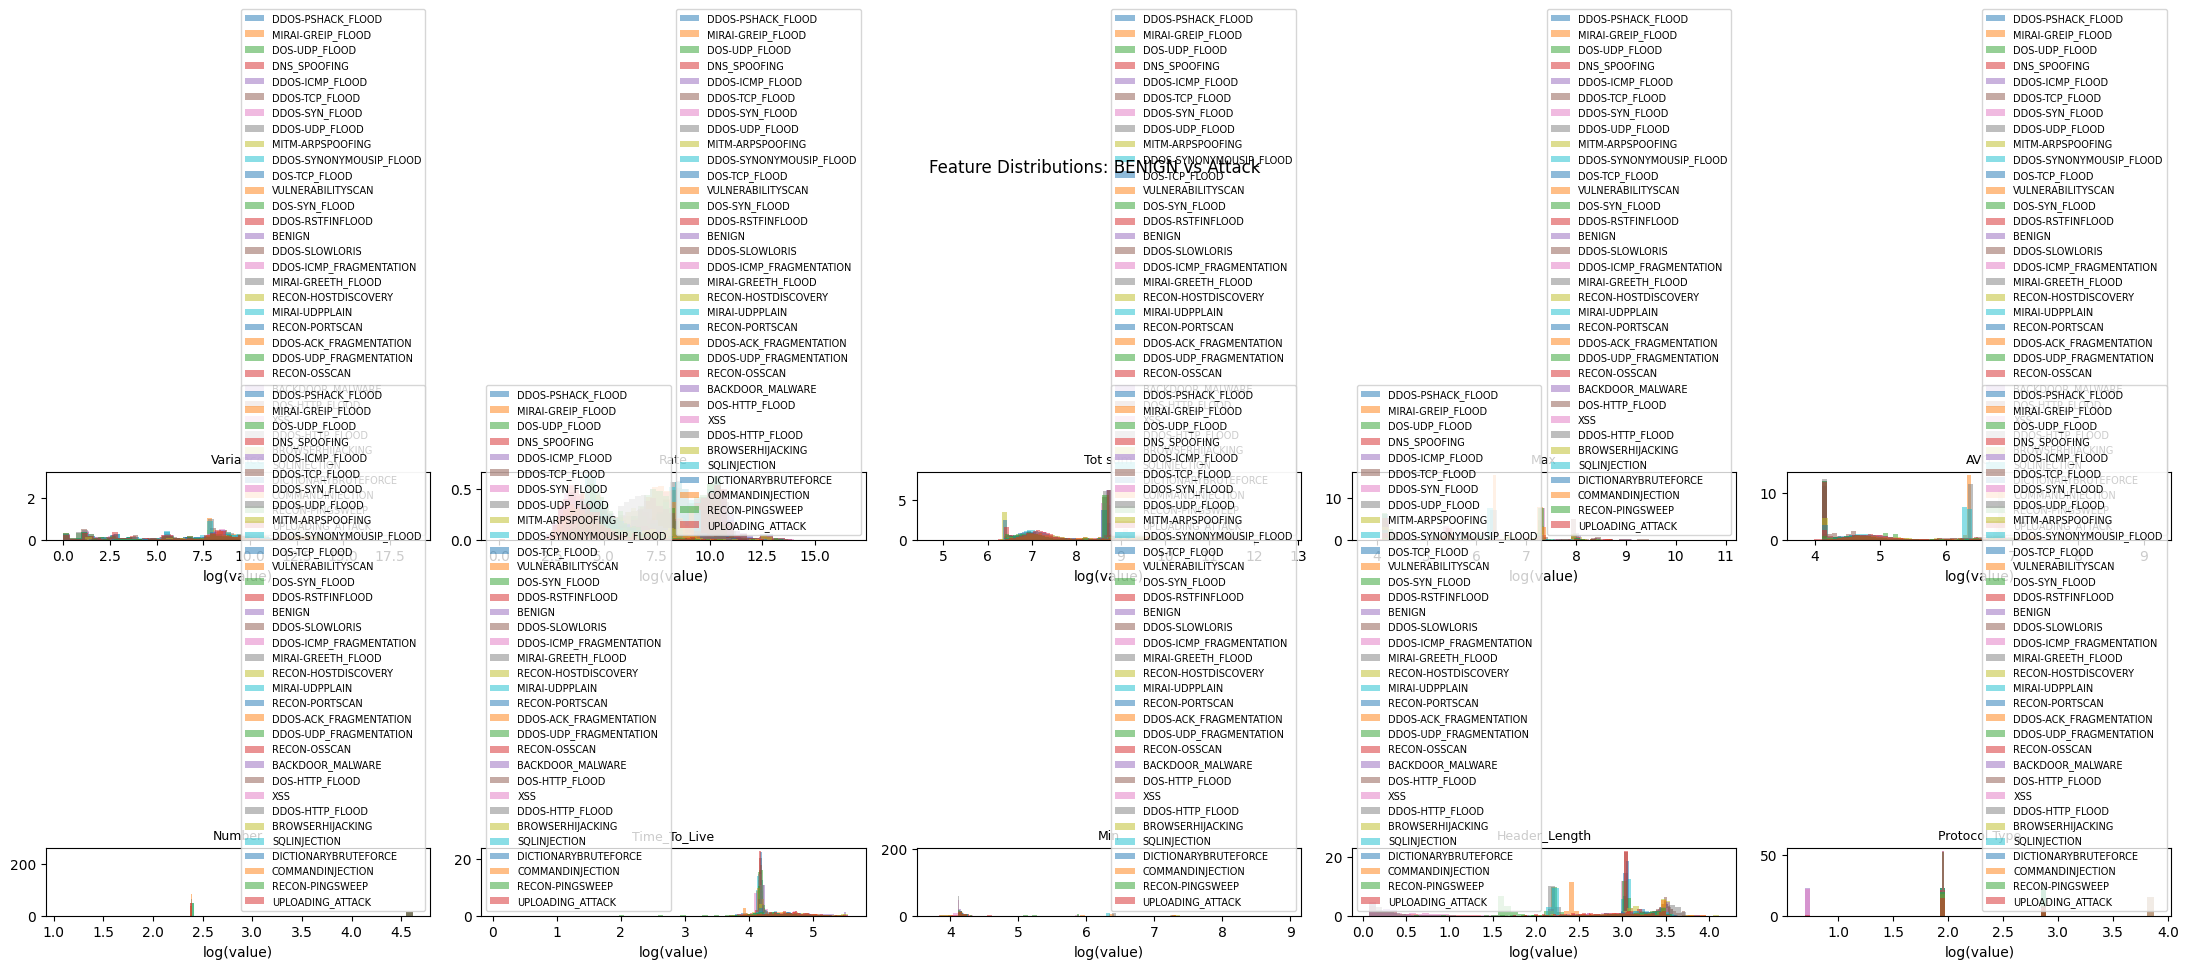

In [15]:
# Identify which features are most useful for classification (which features are good a separating classes)
benign = df_reduced[df_reduced['Label'] == 'BENIGN']
attack = df_reduced[df_reduced['Label'] != 'BENIGN']

benign = benign.iloc[:, :-1]
attack = attack.iloc[:, :-1]

diff = (attack.mean() - benign.mean()).abs().sort_values(ascending=False)
print(diff.head(10))

key_features = diff.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    for label in df_reduced['Label'].unique():
        subset = df_reduced[df_reduced['Label'] == label][feature].dropna()
        subset = subset[subset > 0]  # log scale requires positive values
        axes[i].hist(np.log1p(subset), bins=50, alpha=0.5, label=label, density=True)
    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel('log(value)')
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions: BENIGN vs Attack', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions_IoT2023.png', dpi=150, bbox_inches='tight')

## 8. Attack Type Breakdown

                  Label   count  percentage
         DDOS-UDP_FLOOD 1964069      9.3506
        DDOS-ICMP_FLOOD 1907549      9.0815
          DOS-UDP_FLOOD 1851255      8.8135
         DDOS-SYN_FLOOD 1764592      8.4009
      DDOS-PSHACK_FLOOD 1641896      7.8168
         DDOS-TCP_FLOOD 1560610      7.4298
       DDOS-RSTFINFLOOD 1255783      5.9786
DDOS-SYNONYMOUSIP_FLOOD 1171372      5.5767
          DOS-SYN_FLOOD 1138613      5.4208
          DOS-TCP_FLOOD 1120179      5.3330
                 BENIGN 1047308      4.9861
     MIRAI-GREETH_FLOOD  897596      4.2733
         MIRAI-UDPPLAIN  767297      3.6530
      MIRAI-GREIP_FLOOD  694290      3.3054
DDOS-ICMP_FRAGMENTATION  431149      2.0526
      VULNERABILITYSCAN  356322      1.6964
 DDOS-UDP_FRAGMENTATION  273392      1.3016
 DDOS-ACK_FRAGMENTATION  271535      1.2927
       MITM-ARPSPOOFING  269044      1.2809
           DNS_SPOOFING  167017      0.7951
    RECON-HOSTDISCOVERY  127869      0.6088
           RECON-OSSCAN   92323 

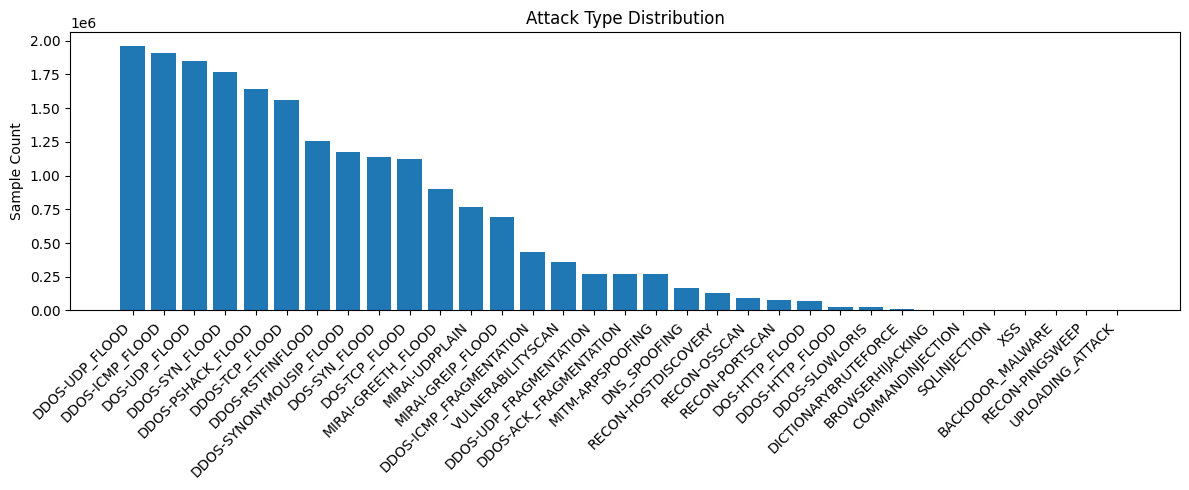

In [17]:
attack_counts = (
    df_complete.groupby('Label')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
attack_counts['percentage'] = (attack_counts['count'] / len(df_complete) * 100).round(4)
print(attack_counts.to_string(index=False))



attack_only = attack_counts[attack_counts['Label'] != 'BENIGN']

plt.figure(figsize=(12, 5))
plt.bar(attack_only['Label'], attack_only['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Attack Type Distribution')
plt.ylabel('Sample Count')
plt.tight_layout()
plt.savefig('attack_breakdown_IoT2023.png', dpi=150, bbox_inches='tight')

In [18]:
print('Label' in df_reduced.columns)
print(df_reduced.shape)

True
(21004674, 30)


In [19]:
# Export to CSV
df_reduced.to_csv('data/df_reduced_IoT2023.csv', index=False)